# Project 1: Momentum Resolution

In the following, all measurements are in metres, resp. radians.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from src.tracking import (
    trajectory_fun, trajectory_fun_linear, manual_least_squares,
    manual_least_squares_after, single_trajectory,
    simulate_trajectories, display_simulation, residuals_and_pulls,
    generating_x0, generating_s0,
    compute_pT_reco_classic, compute_pT_reco_mc,
)
from src.tracking import n_beforeB, n_afterB, D_z, L, cell_width, n_planes
from src.tracking import z_start_after_B, z_begin_magnetic_field, z_end_magnetic_field

## Tracking resolution

### Single trajectory

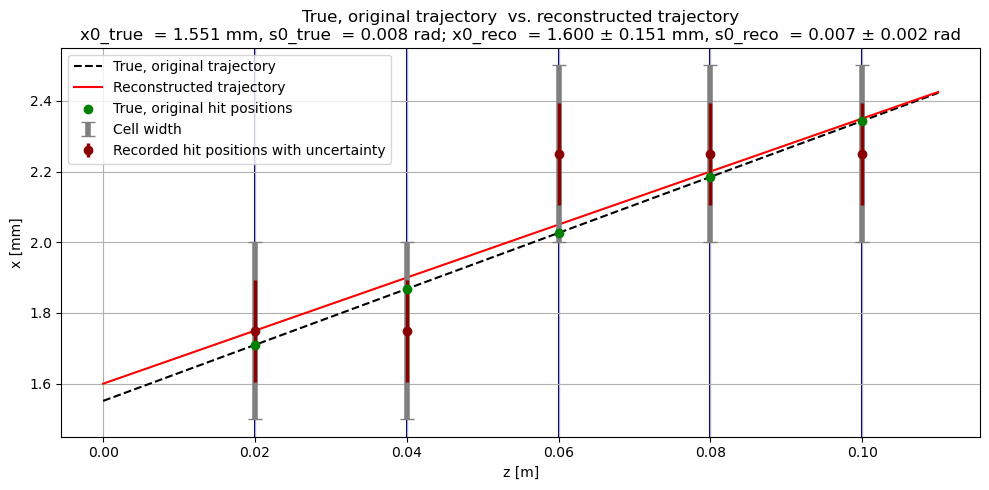

x0_true  = 1.551 mm
x0_reco  = 1.600 ± 0.151 mm
s0_true  = 0.008 rad
s0_reco  = 0.007 ± 0.002 rad


In [2]:
np.random.seed(14)

s0_true, s0_reco, std_s0_reco, slope_true, slope_reco, std_slope_reco, x0_true, x0_reco, std_x0_reco, z_positions, x_positions, cells_hit_middle, std_hit = single_trajectory()

# Plotting
grid = np.linspace(0, z_positions[-1] + D_z/2, num = 1001)
true_traj_z = trajectory_fun(grid, x0_true, s0_true)  # Using the angle, because this was how the task was given
reco_traj_z = trajectory_fun_linear(grid, x0_reco, slope_reco) # Using the slope, because this was how we fitted

plt.figure(figsize=(10,5))
for z in z_positions:
    plt.axvline(x=z, color="darkblue", linestyle='-', linewidth=1.5, zorder=0) # Detector planes
# I multiplied everything by thousand such that the y-axis has millimetre values
plt.plot(grid, 1000*true_traj_z, "k--", label = "True, original trajectory") 
plt.plot(grid, 1000*reco_traj_z, "r-", label = "Reconstructed trajectory")
plt.scatter(z_positions, 1000*x_positions, color = "g", label = "True, original hit positions", zorder = 3)
plt.errorbar(z_positions, 1000*cells_hit_middle, yerr = 1000*cell_width/2, fmt='none', color='grey', elinewidth=4, capsize=5, label="Cell width")
plt.errorbar(z_positions, 1000*cells_hit_middle, yerr = 1000*std_hit, fmt = "o", color = "darkred", linewidth = 2.5, label = "Recorded hit positions with uncertainty")

plt.xlabel("z [m]")
plt.ylabel("x [mm]")
plt.grid()
plt.legend()
plt.title(f"True, original trajectory  vs. reconstructed trajectory\nx0_true  = {x0_true*1000:.3f} mm, s0_true  = {s0_true:.3f} rad; x0_reco  = {x0_reco*1000:.3f} ± {std_x0_reco*1000:.3f} mm, s0_reco  = {s0_reco:.3f} ± {std_s0_reco:.3f} rad")
plt.tight_layout()
#plt.savefig("Single_trajectory")
plt.show()


print(f"x0_true  = {x0_true*1000:.3f} mm")
print(f"x0_reco  = {x0_reco*1000:.3f} ± {std_x0_reco*1000:.3f} mm")
print(f"s0_true  = {s0_true:.3f} rad")
print(f"s0_reco  = {s0_reco:.3f} ± {std_s0_reco:.3f} rad")



### Multiple trajectories

We first tried to fit the trajectory with curve_fit. First, we fitted with modelling the uncertainty the direct way, but because tan(s0) is nonlinear, the impact of errors in s0 grows with s0, and the uncertainty model of curve_fit doesn’t fully capture that, so the unlinearity of tan(s0) lead to a strong underestimation of the uncertainty of s0. <br> <br>

Next, we tried fitting with curve_fit, but introducing the linear function trajectory_fun_linear to get rid of the nonlinearity of the tangent (of course, there was a certain preparation and postprocessing of the data). The uncertainty was less underestimated, but still present to a significant extent. <br> <br>

Finally, we decided to fit the linear data ourselves by creating a function that would do a weighted linear regression based on the least squares criterion. The uncertainties are now represented very well (though it takes a lot longer). <br> <br>

Note that this underestimation of the uncertainty was always visible by the too large standard deviation of the pulls - especially of those of the angle.

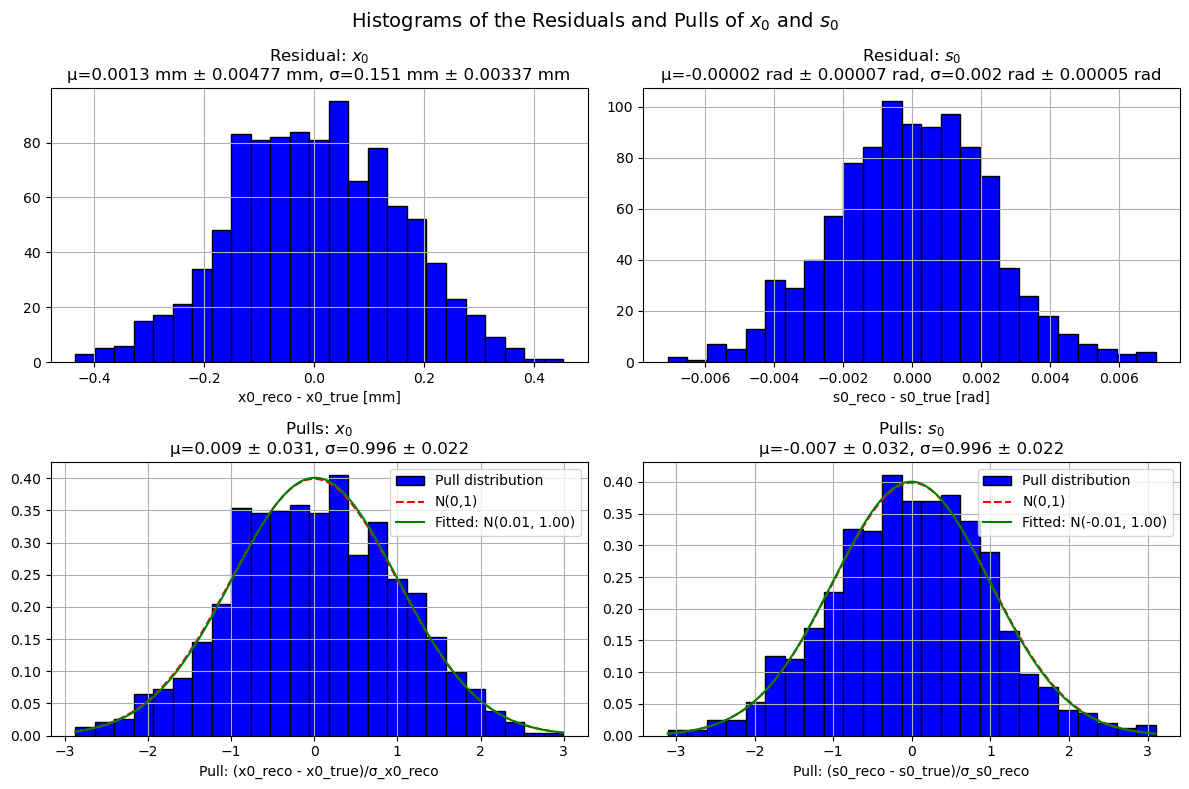

In [3]:
n_trajectories = 1000

np.random.seed(14)

# Arrays for the residuals and for the pulls
resi_s0 = np.full(n_trajectories, np.nan)
resi_x0 = np.full(n_trajectories, np.nan)

pulls_s0 = np.full(n_trajectories, np.nan)
pulls_x0 = np.full(n_trajectories, np.nan)


for i in range(n_trajectories):
    # Get single trajectory
    s0_true, s0_reco, std_s0_reco, slope_true, slope_reco, std_slope_reco, x0_true, x0_reco, std_x0_reco, z_positions, x_positions, cells_hit_middle, std_hit = single_trajectory()

    # Residuals
    resi_s0[i] = s0_reco - s0_true
    resi_x0[i] = x0_reco - x0_true

    # pull = (reconstructed_quantity - generated_quantity)/uncertainty_on_reconstructed_quantity
    pulls_s0[i] = (s0_reco - s0_true)/std_s0_reco
    pulls_x0[i] = (x0_reco - x0_true)/std_x0_reco


# Taking the mean and standard deviation for the residuals
mean_resi_s0 = np.mean(resi_s0)
mean_resi_x0 = np.mean(resi_x0)

std_resi_s0 = np.std(resi_s0)
std_resi_x0 = np.std(resi_x0)


# Uncertainties of estimators of residuals assuming gaussian distribution
mean_resi_s0_error = std_resi_s0/np.sqrt(n_trajectories)
mean_resi_x0_error = std_resi_x0/np.sqrt(n_trajectories)
std_resi_s0_error = std_resi_s0/np.sqrt(2 * n_trajectories - 2)
std_resi_x0_error = std_resi_x0/np.sqrt(2 * n_trajectories - 2)


# 2x2 subplot figure
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Plot these distributions as histograms
axs[0, 0].hist(resi_x0 * 1000, bins = 25, color = "blue", edgecolor = "black")
axs[0, 0].set_title(f"Residual: $x_0$\nμ={mean_resi_x0 * 1000:.4f} mm ± {mean_resi_x0_error * 1000:.5f} mm, σ={std_resi_x0 * 1000:.3f} mm ± {std_resi_x0_error * 1000:.5f} mm")
axs[0, 0].set_xlabel("x0_reco - x0_true [mm]")
axs[0, 0].grid()

axs[0, 1].hist(resi_s0, bins = 25, color = "blue", edgecolor = "black")
axs[0, 1].set_title(f"Residual: $s_0$\nμ={mean_resi_s0:.5f} rad ± {mean_resi_s0_error:.5f} rad, σ={std_resi_s0:.3f} rad ± {std_resi_s0_error:.5f} rad")
axs[0, 1].set_xlabel("s0_reco - s0_true [rad]")
axs[0, 1].grid()


# Taking the mean and standard deviation for the pulls
mean_pulls_s0 = np.mean(pulls_s0)
mean_pulls_x0 = np.mean(pulls_x0)

std_pulls_s0 = np.std(pulls_s0)
std_pulls_x0 = np.std(pulls_x0)


# Uncertainties of estimators of pulls assuming gaussian distribution
mean_pulls_s0_error = std_pulls_s0/np.sqrt(n_trajectories)
mean_pulls_x0_error = std_pulls_x0/np.sqrt(n_trajectories)
std_pulls_s0_error = std_pulls_s0/np.sqrt(2 * n_trajectories - 2)
std_pulls_x0_error = std_pulls_x0/np.sqrt(2 * n_trajectories - 2)


# Plot the distributions as histograms with overlayed Gaussian distributions
axs[1, 0].hist(pulls_x0, bins=25, density=True, color="blue", edgecolor="black", label="Pull distribution")
x_vals = np.linspace(min(pulls_x0), max(pulls_x0), 500)
axs[1, 0].plot(x_vals, norm.pdf(x_vals, 0, 1), 'r--', label="N(0,1)")
axs[1, 0].plot(x_vals, norm.pdf(x_vals, mean_pulls_x0, std_pulls_x0), 'g-', label=f"Fitted: N({mean_pulls_x0:.2f}, {std_pulls_x0:.2f})")
axs[1, 0].set_title(f"Pulls: $x_0$\nμ={mean_pulls_x0:.3f} ± {mean_pulls_x0_error:.3f}, σ={std_pulls_x0:.3f} ± {std_pulls_x0_error:.3f}")
axs[1, 0].set_xlabel("Pull: (x0_reco - x0_true)/σ_x0_reco")
axs[1, 0].legend()
axs[1, 0].grid()

axs[1, 1].hist(pulls_s0, bins=25, density=True, color="blue", edgecolor="black", label="Pull distribution")
x_vals = np.linspace(min(pulls_s0), max(pulls_s0), 500)
axs[1, 1].plot(x_vals, norm.pdf(x_vals, 0, 1), 'r--', label="N(0,1)")
axs[1, 1].plot(x_vals, norm.pdf(x_vals, mean_pulls_s0, std_pulls_s0), 'g-', label=f"Fitted: N({mean_pulls_s0:.2f}, {std_pulls_s0:.2f})")
axs[1, 1].set_title(f"Pulls: $s_0$\nμ={mean_pulls_s0:.3f} ± {mean_pulls_s0_error:.3f}, σ={std_pulls_s0:.3f} ± {std_pulls_s0_error:.3f}")
axs[1, 1].set_xlabel("Pull: (s0_reco - s0_true)/σ_s0_reco")
axs[1, 1].legend()
axs[1, 1].grid()

plt.suptitle("Histograms of the Residuals and Pulls of $x_0$ and $s_0$", fontsize= 14)

plt.tight_layout()
#plt.savefig("Multiple_trajectories")
plt.show()
    

## Momentum resolution

### Setup
The experimental apparatus is constructed with the z-axis horizontal, the x-axis vertical and the y-axis perpendicular to the drawing of the experiment (i.e. exiting the screen).
z positive to the right, x positive upwards and y positive exiting in the direction of the person looking at the drawing.

The experiment setup consists of five detection planes placed along the z-axis, parallel to the x-axis, and placed 2cm apart.
The magnetic field is directed towards the positive y-axis, with an intensity of 0.5T, and is 10cm long along the z-axis. At the end of the magnetic field
there are three detection planes, also parallel to the x-axis and placed 2cm apart.

In [4]:
nr_trajectories = 100

### Part a), warm-up
As a warm-up exercise, generate a single particle trajectory for a particle with pT = 0.3 GeV, x0 true drawn from a Gaussian distribution with mean 0 and standard deviation 1 mm and with s0 true drawn from a Gaussian distribution with mean 0 and standard deviation 0.1 rad.
Randomly assign charge q = +1 or q = −1 to the particle.
(a) Extrapolate the trajectory to the z positions of the eight detection layers (five before and three after the magnet). Generate hit positions as you did in Sec. 3. Draw the trajectory and the hit positions with their uncertainties.
### Part b)
(b) Fit straight lines to the hits in the stations before and after the magnet and determine pT reco and its uncertainty from the angle between these two lines

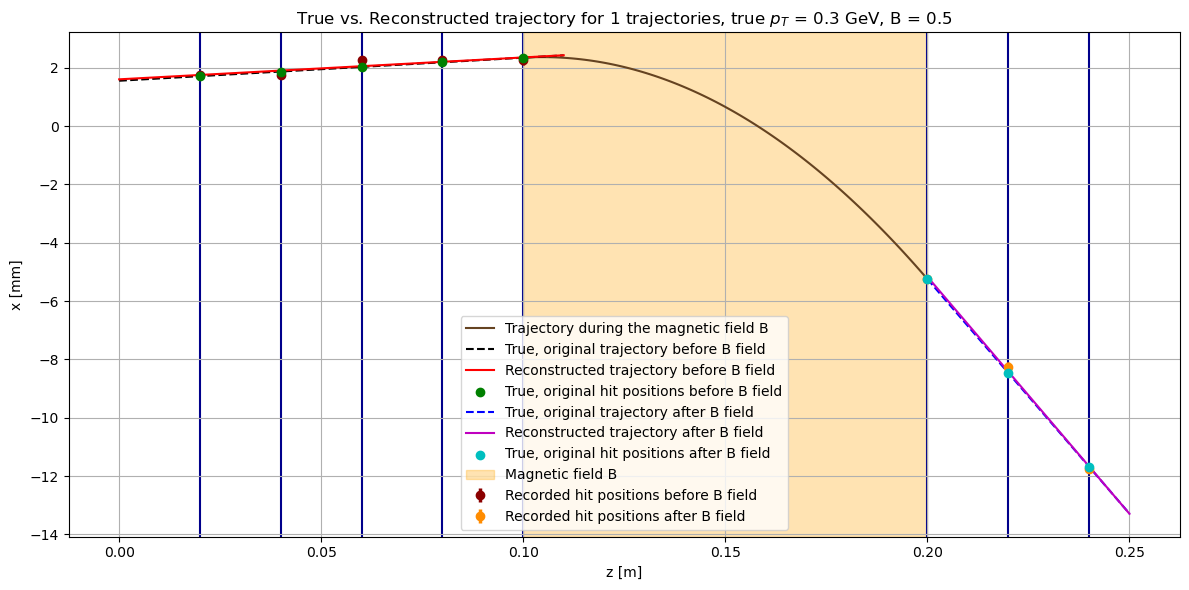

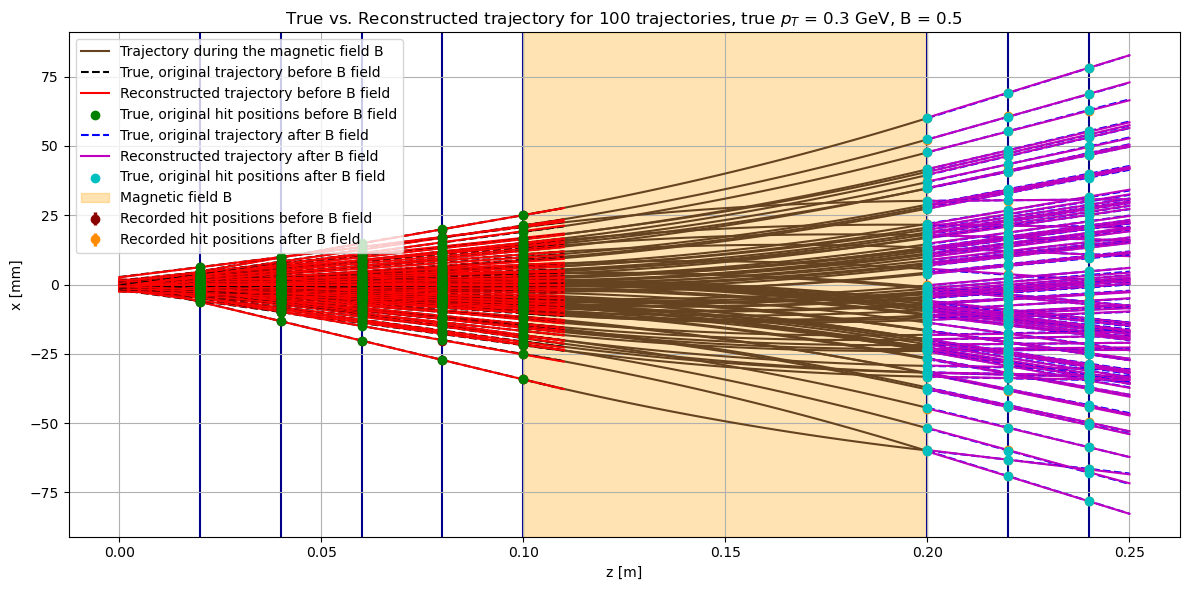

In [5]:
# Part a)
# Warm-up

np.random.seed(14)

B = 0.5
pT_true = 0.3

# 1 trajectory
plt.figure(figsize=(12,6))
z_positions_before_B, z_positions_after_B, x_positions_before_B, x_positions_after_B, grid_before_B, grid_after_B, true_traj_z_before_B, true_traj_z_after_B, reco_traj_z_before_B, reco_traj_z_after_B, cells_hit_middle_before_B, cells_hit_middle_after_B, std_hit, s_after_B, s0_reco_before_B, s0_reco_after_B, std_x0_reco_before_B, std_s0_reco_before_B, std_x0_reco_after_B, std_s0_reco_after_B, s0, q_list = simulate_trajectories(1, pT_true, B)
display_simulation(z_positions_before_B, z_positions_after_B, x_positions_before_B, x_positions_after_B, grid_before_B, grid_after_B, true_traj_z_before_B, true_traj_z_after_B, reco_traj_z_before_B, reco_traj_z_after_B, cells_hit_middle_before_B, cells_hit_middle_after_B, std_hit, s_after_B, std_x0_reco_before_B, std_s0_reco_before_B, std_x0_reco_after_B, std_s0_reco_after_B, s0, q_list, 1, pT_true, B)

# 100 trajectories
plt.figure(figsize=(12,6))
z_positions_before_B, z_positions_after_B, x_positions_before_B, x_positions_after_B, grid_before_B, grid_after_B, true_traj_z_before_B, true_traj_z_after_B, reco_traj_z_before_B, reco_traj_z_after_B, cells_hit_middle_before_B, cells_hit_middle_after_B, std_hit, s_after_B, s0_reco_before_B, s0_reco_after_B, std_x0_reco_before_B, std_s0_reco_before_B, std_x0_reco_after_B, std_s0_reco_after_B, s0, q_list = simulate_trajectories(100, pT_true, B)
display_simulation(z_positions_before_B, z_positions_after_B, x_positions_before_B, x_positions_after_B, grid_before_B, grid_after_B, true_traj_z_before_B, true_traj_z_after_B, reco_traj_z_before_B, reco_traj_z_after_B, cells_hit_middle_before_B, cells_hit_middle_after_B, std_hit, s_after_B, std_x0_reco_before_B, std_s0_reco_before_B, std_x0_reco_after_B, std_s0_reco_after_B, s0, q_list, 100, pT_true, B)


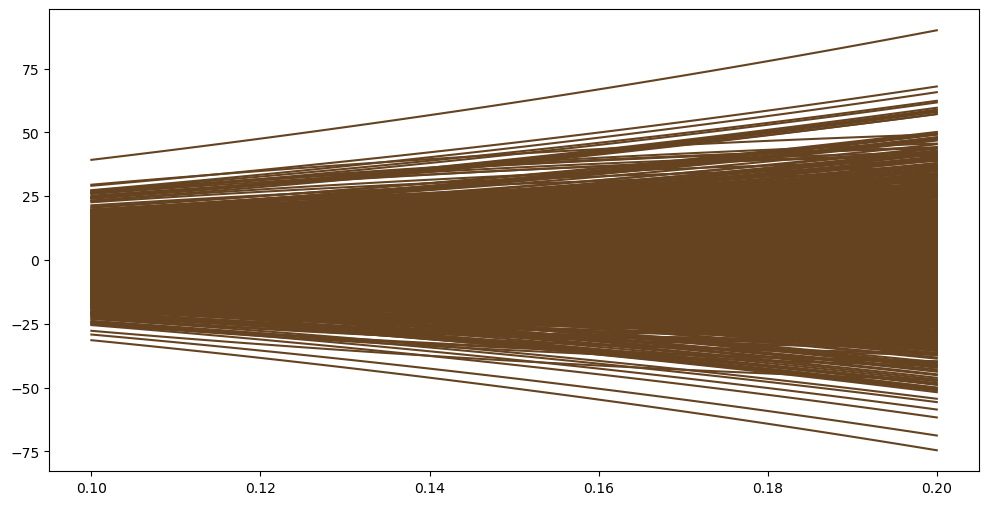

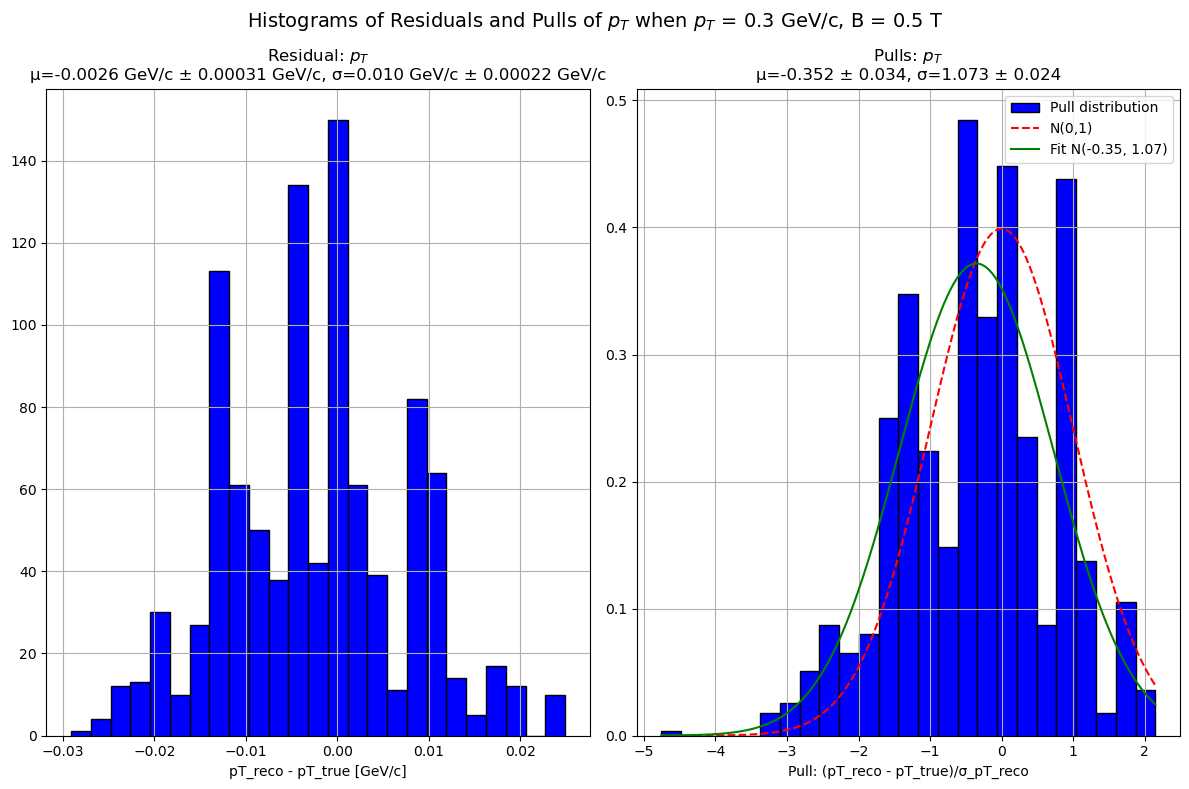

In [6]:
np.random.seed(14)

B = 0.5
pT_true = 0.3

plt.figure(figsize=(12,6))
z_positions_before_B, z_positions_after_B, x_positions_before_B, x_positions_after_B, grid_before_B, grid_after_B, true_traj_z_before_B, true_traj_z_after_B, reco_traj_z_before_B, reco_traj_z_after_B, cells_hit_middle_before_B, cells_hit_middle_after_B, std_hit, s_after_B, s0_reco_before_B, s0_reco_after_B, std_x0_reco_before_B, std_s0_reco_before_B, std_x0_reco_after_B, std_s0_reco_after_B, s0, q_list = simulate_trajectories(1000, pT_true, B, plot_circular_path= True)
#display_simulation(z_positions_before_B, z_positions_after_B, x_positions_before_B, x_positions_after_B, grid_before_B, grid_after_B, true_traj_z_before_B, true_traj_z_after_B, reco_traj_z_before_B, reco_traj_z_after_B, cells_hit_middle_before_B, cells_hit_middle_after_B, std_hit, s_after_B, std_x0_reco_before_B, std_s0_reco_before_B, std_x0_reco_after_B, std_s0_reco_after_B, s0, q_list, 1000, pT_true, B)
residuals_and_pulls(s_after_B, 1000, s0_reco_before_B, s0_reco_after_B, std_s0_reco_before_B, std_s0_reco_after_B, q_list, B, L, pT_true, pt_calculation_way= "classic")

Repeat the exercise for pT true = 0.1, 1, 2, 5, 10, 20 GeV/c. Observe how the resolution on pT changes as a function of pT true.

Repeat the exercise for pT true = 0.3 GeV and B = 1.0, 1.5, 2.0 T. Observe how the resolution on pT changes as a function of B.

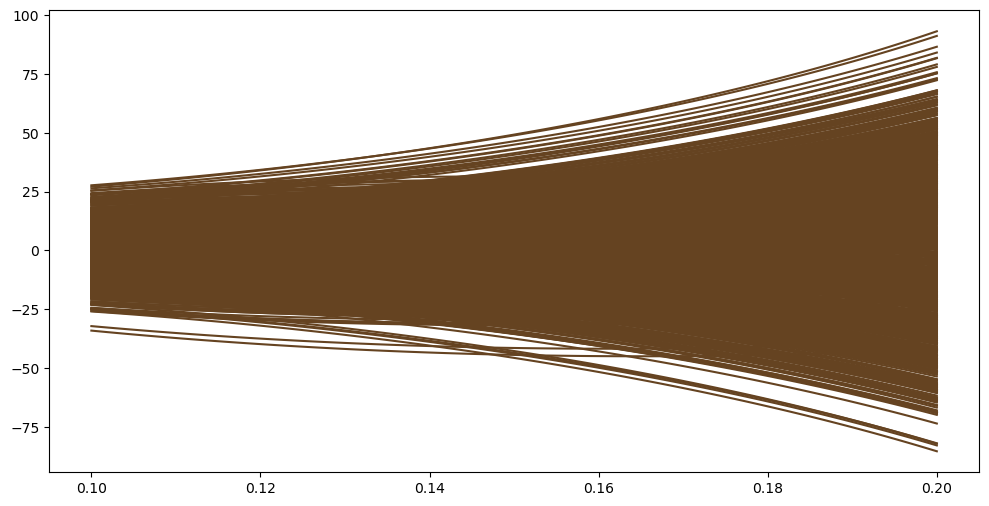

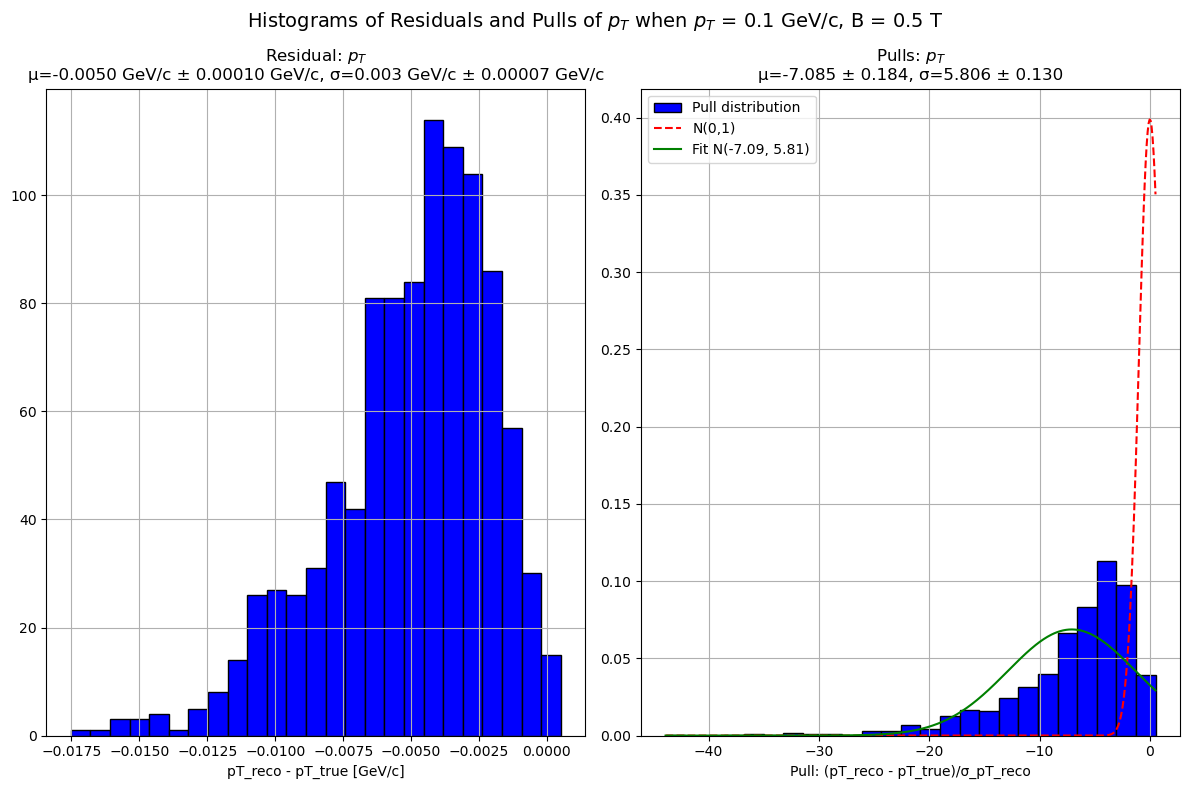

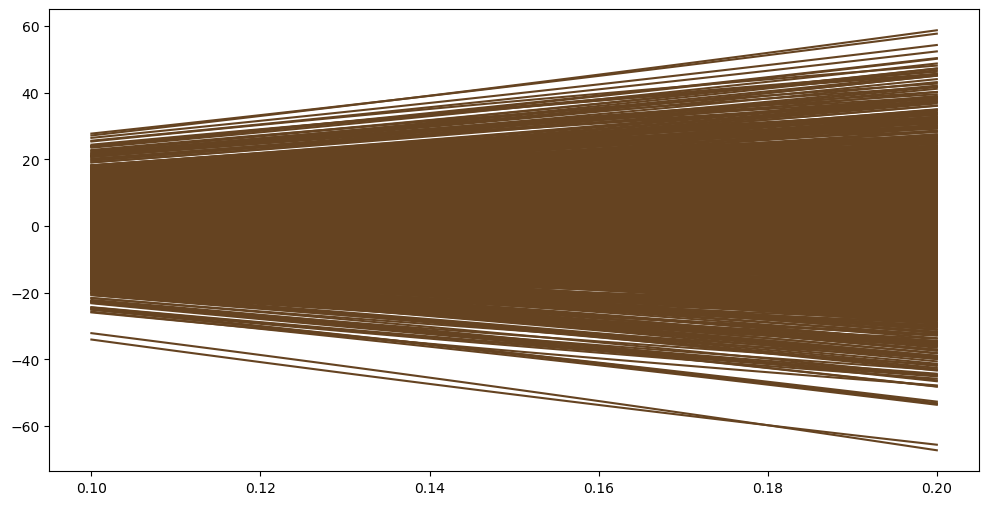

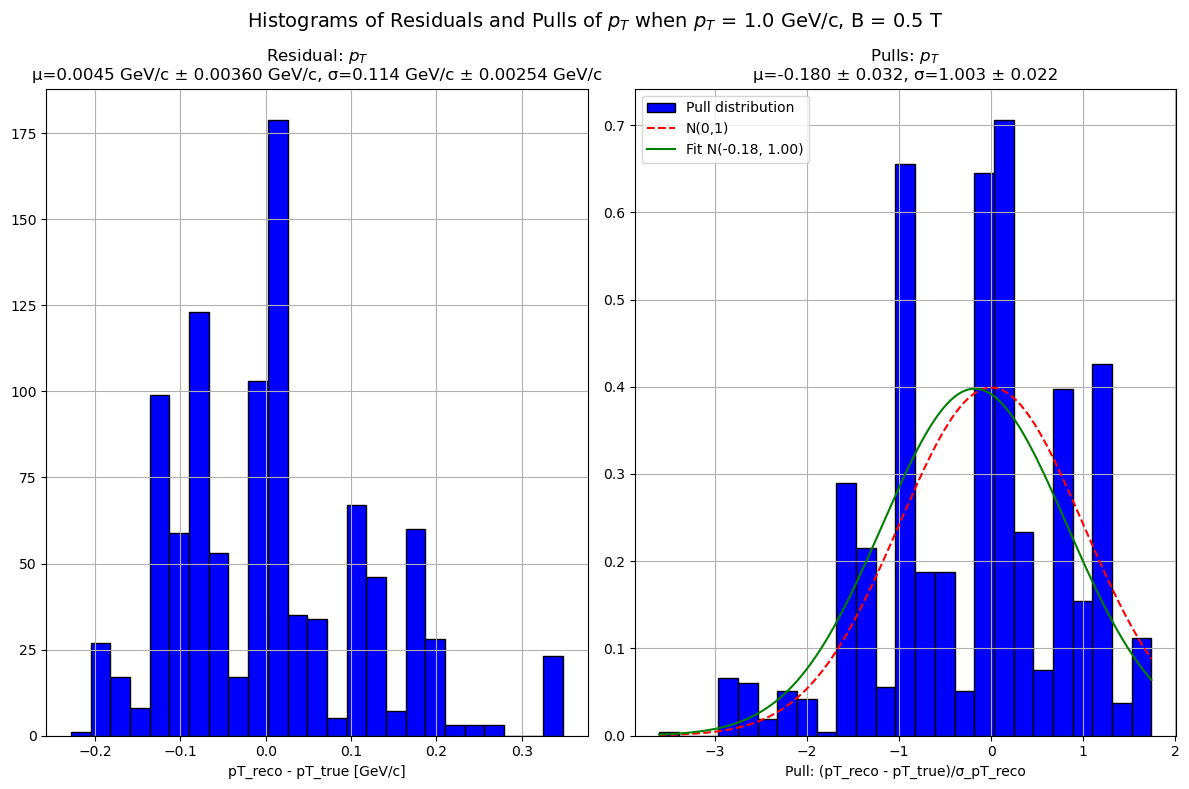

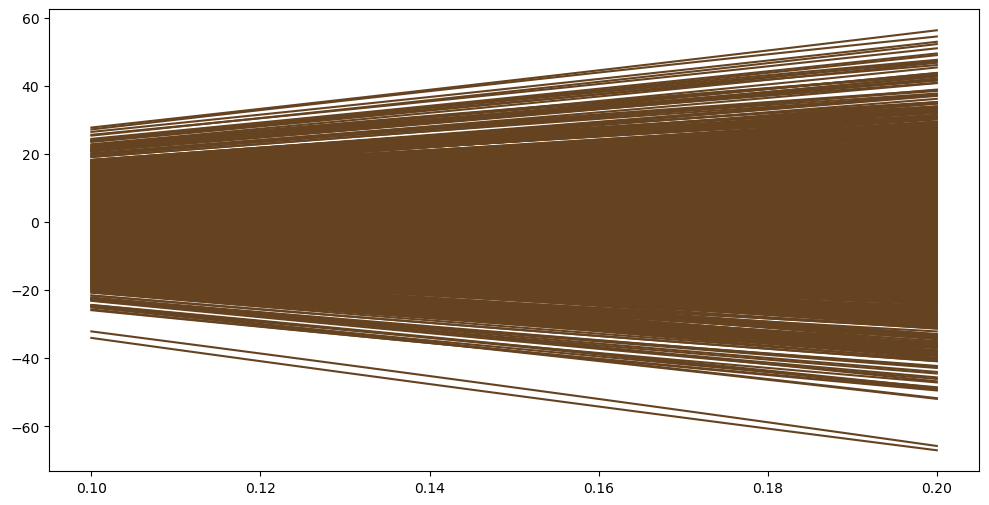

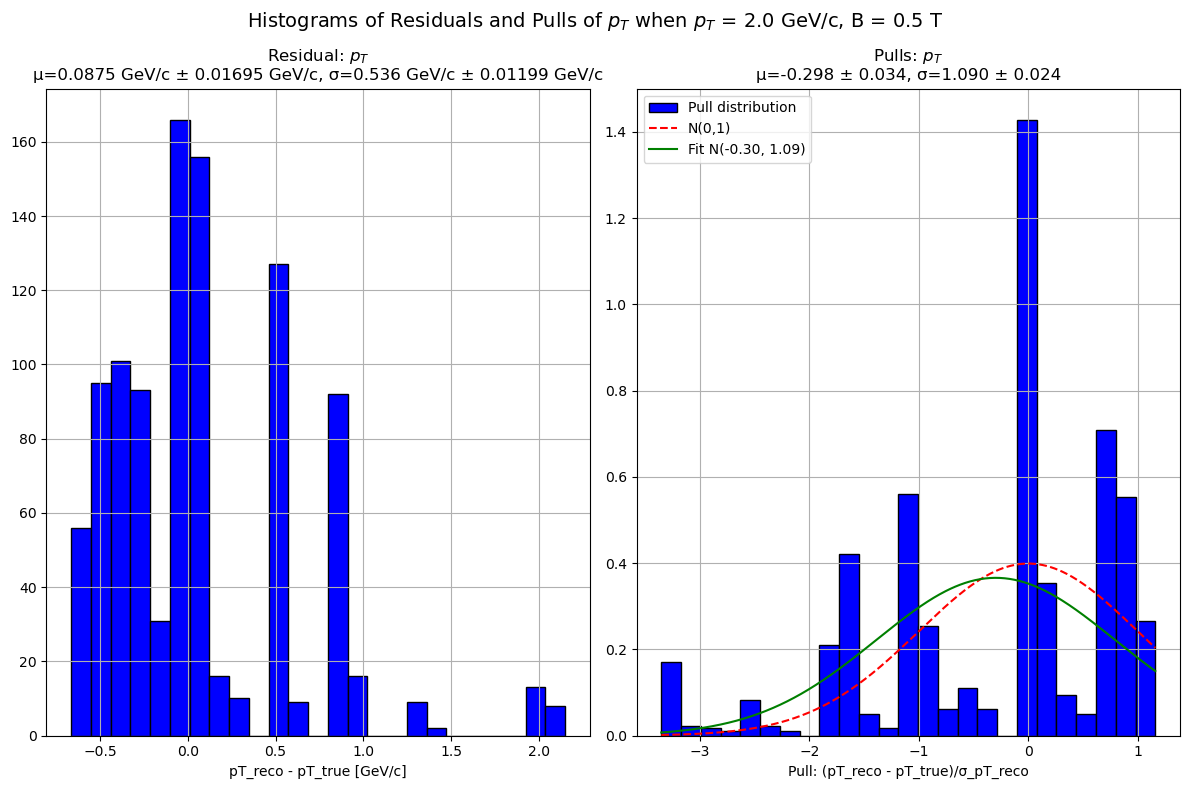

g:\Meine Ablage\UZH Austausch\KAUST\Bewerbung\particle_tracking_redo\final_final\final\particle_tracking-main\particle_tracking-main\src\tracking.py:288: RuntimeWarning: divide by zero encountered in scalar divide
  pT_reco = np.abs((q * B * L) / theta)
g:\Meine Ablage\UZH Austausch\KAUST\Bewerbung\particle_tracking_redo\final_final\final\particle_tracking-main\particle_tracking-main\src\tracking.py:291: RuntimeWarning: divide by zero encountered in scalar divide
  pT_reco_err = np.sqrt((angle_before_B_field_err * (q * B * L) / theta**2)**2 + (angle_after_B_field_err * (q * B * L) / theta**2)**2)
g:\Meine Ablage\UZH Austausch\KAUST\Bewerbung\particle_tracking_redo\final_final\final\particle_tracking-main\particle_tracking-main\src\tracking.py:526: RuntimeWarning: invalid value encountered in divide
  pulls_pT = (pT_reco - pT_true)/pT_reco_err


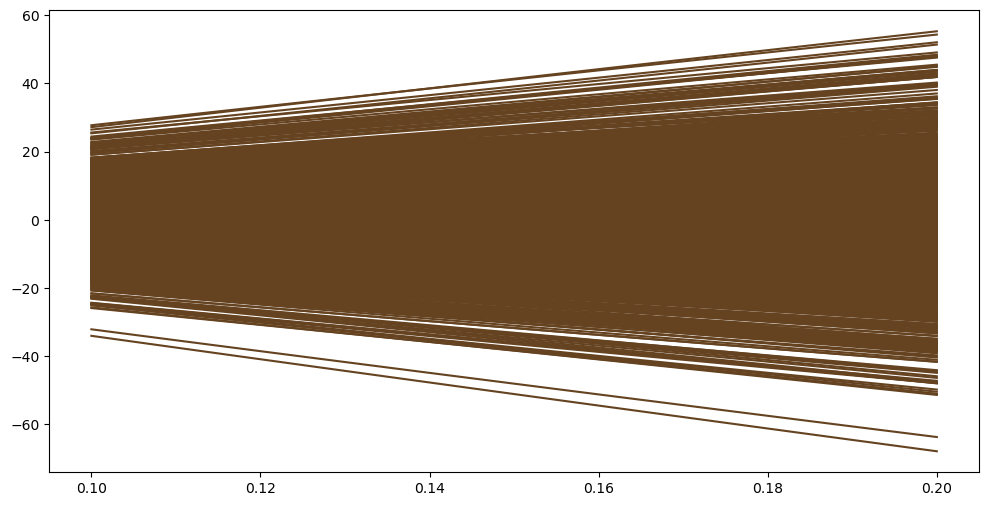

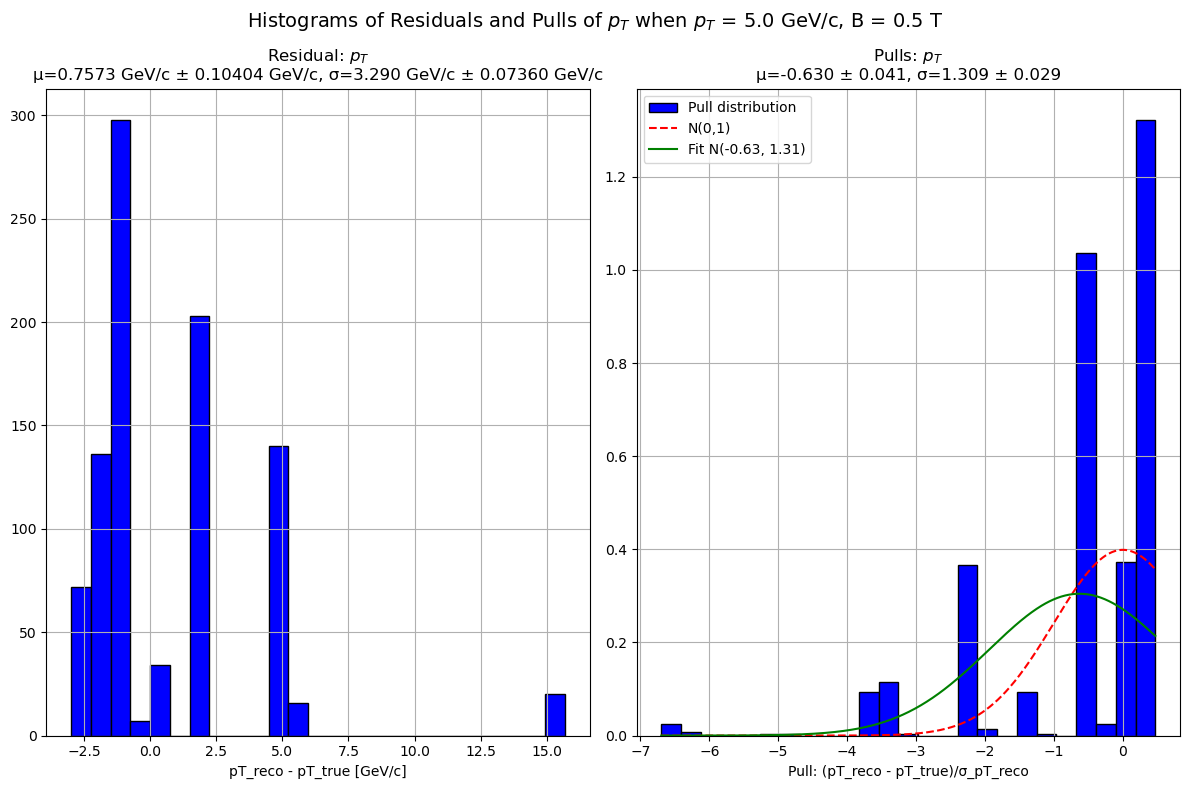

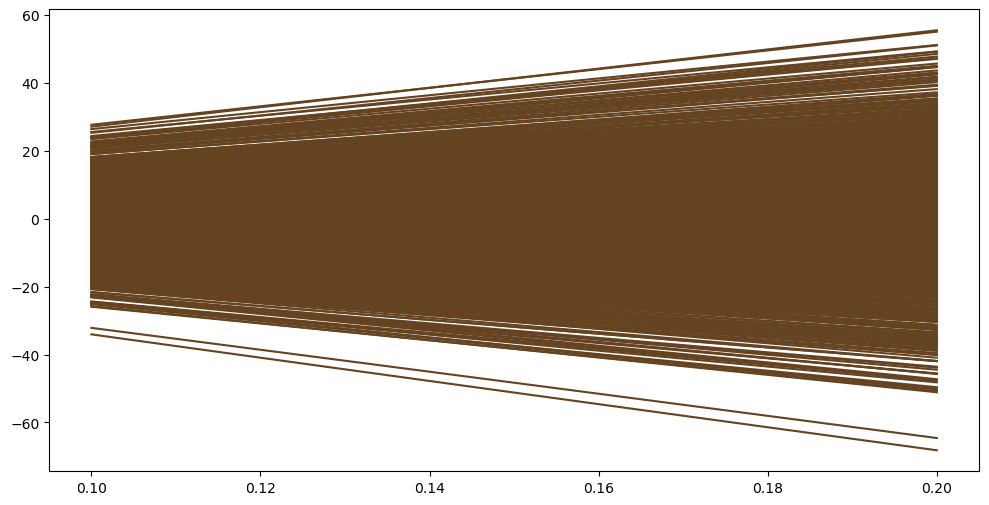

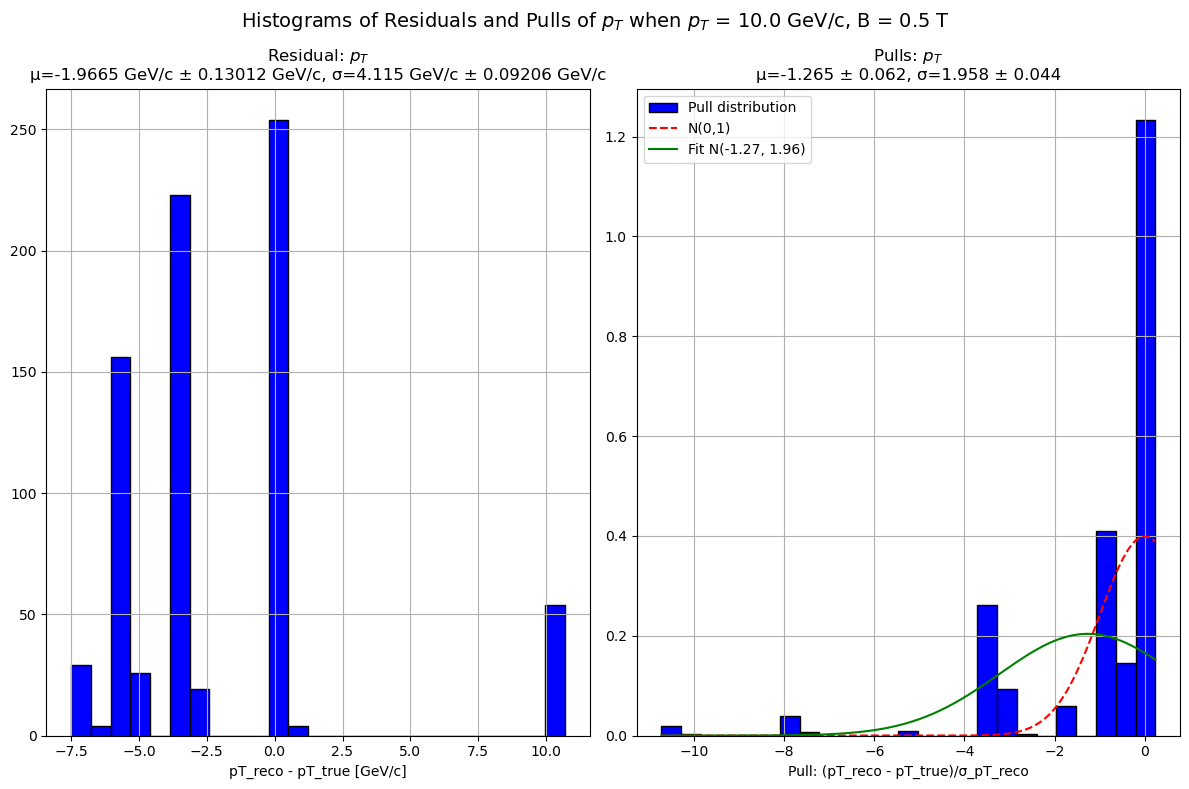

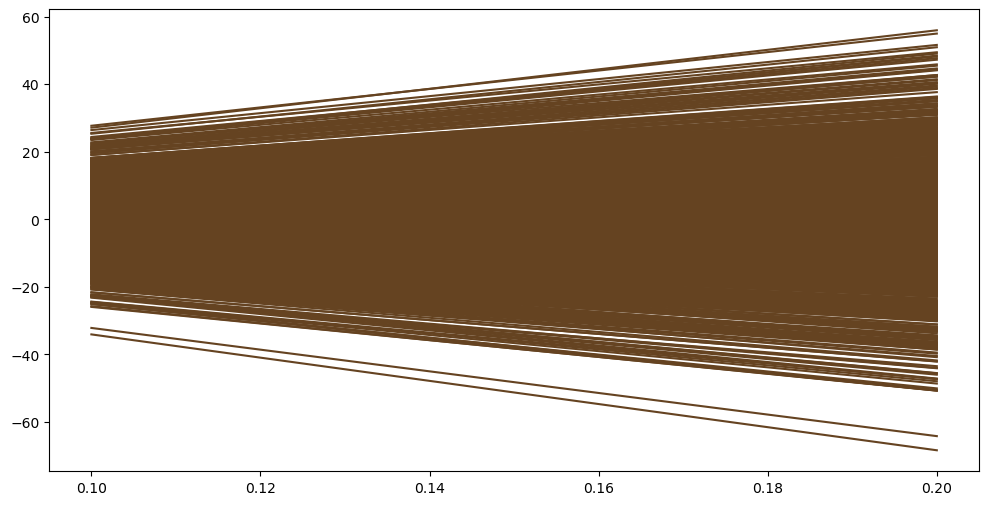

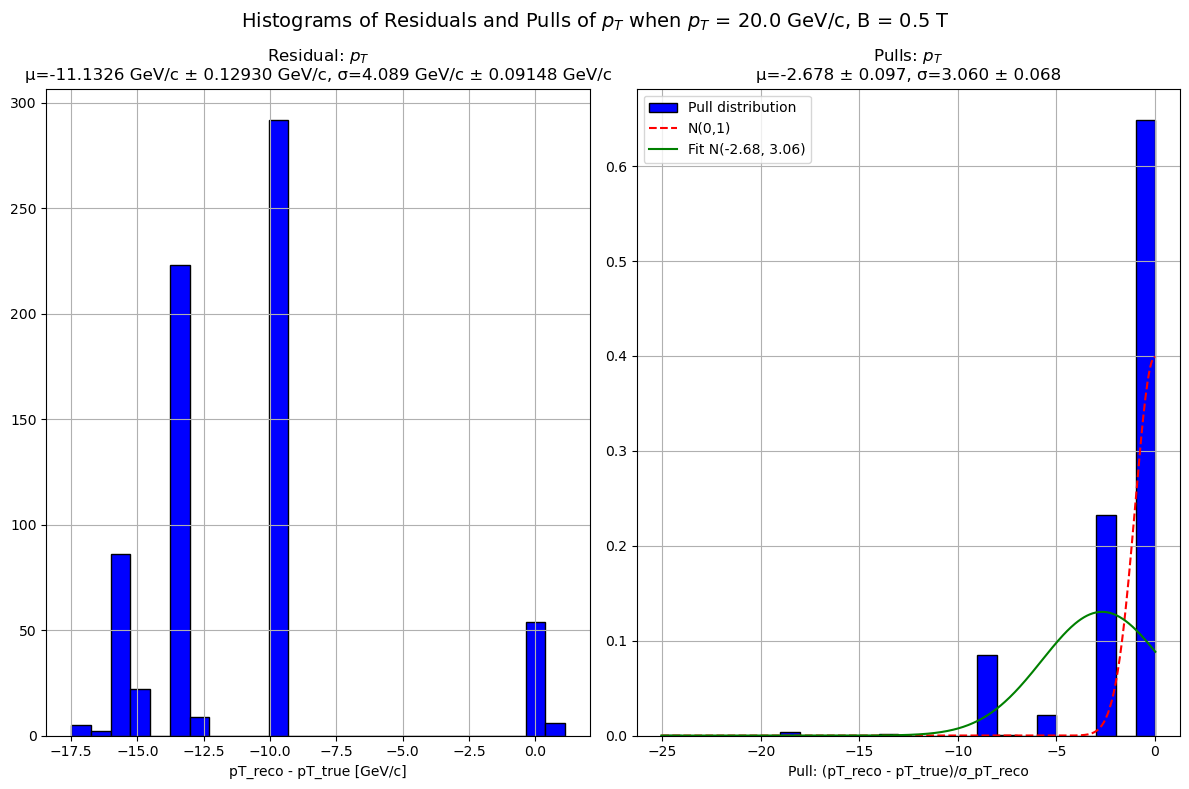

In [7]:
pT_trues = np.array([0.1, 1, 2, 5, 10, 20]) # GeV/c
B = 0.5
nr_trajectories = 1000

# Simulate trajectories for each pT_true value
for pT_true in pT_trues:
    
    np.random.seed(10)

    plt.figure(figsize=(12,6))
    # Specify the numbers of trajectories to be generated
    z_positions_before_B, z_positions_after_B, x_positions_before_B, x_positions_after_B, grid_before_B, grid_after_B, true_traj_z_before_B, true_traj_z_after_B, reco_traj_z_before_B, reco_traj_z_after_B, cells_hit_middle_before_B, cells_hit_middle_after_B, std_hit, s_after_B, s0_reco_before_B, s0_reco_after_B, std_x0_reco_before_B, std_s0_reco_before_B, std_x0_reco_after_B, std_s0_reco_after_B, s0, q_list = simulate_trajectories(nr_trajectories, pT_true, B)
    #display_simulation(z_positions_before_B, z_positions_after_B, x_positions_before_B, x_positions_after_B, grid_before_B, grid_after_B, true_traj_z_before_B, true_traj_z_after_B, reco_traj_z_before_B, reco_traj_z_after_B, cells_hit_middle_before_B, cells_hit_middle_after_B, std_hit, s_after_B, std_x0_reco_before_B, std_s0_reco_before_B, std_x0_reco_after_B, std_s0_reco_after_B, s0, q_list, nr_trajectories, pT_true, B)
    residuals_and_pulls(s_after_B, nr_trajectories, s0_reco_before_B, s0_reco_after_B, std_s0_reco_before_B, std_s0_reco_after_B, q_list, B, L, pT_true, pt_calculation_way= "classic")


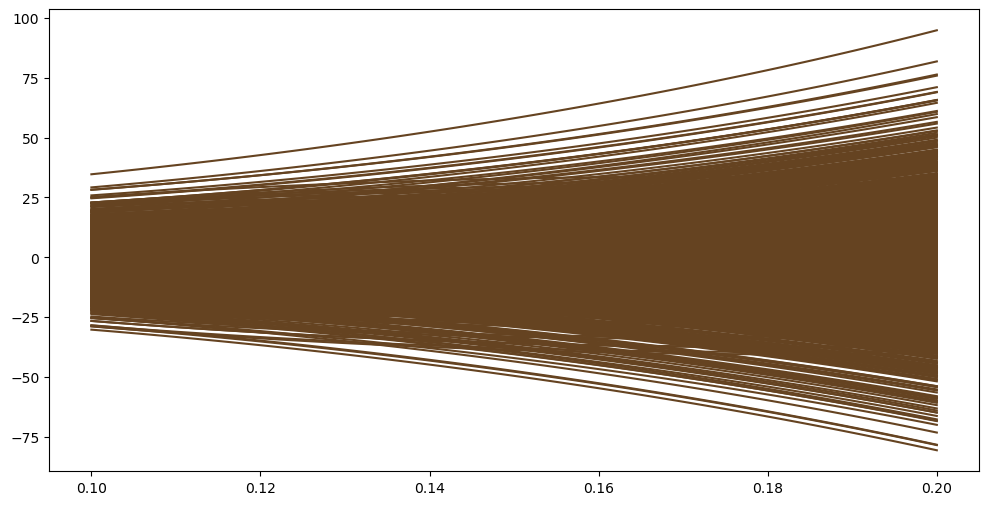

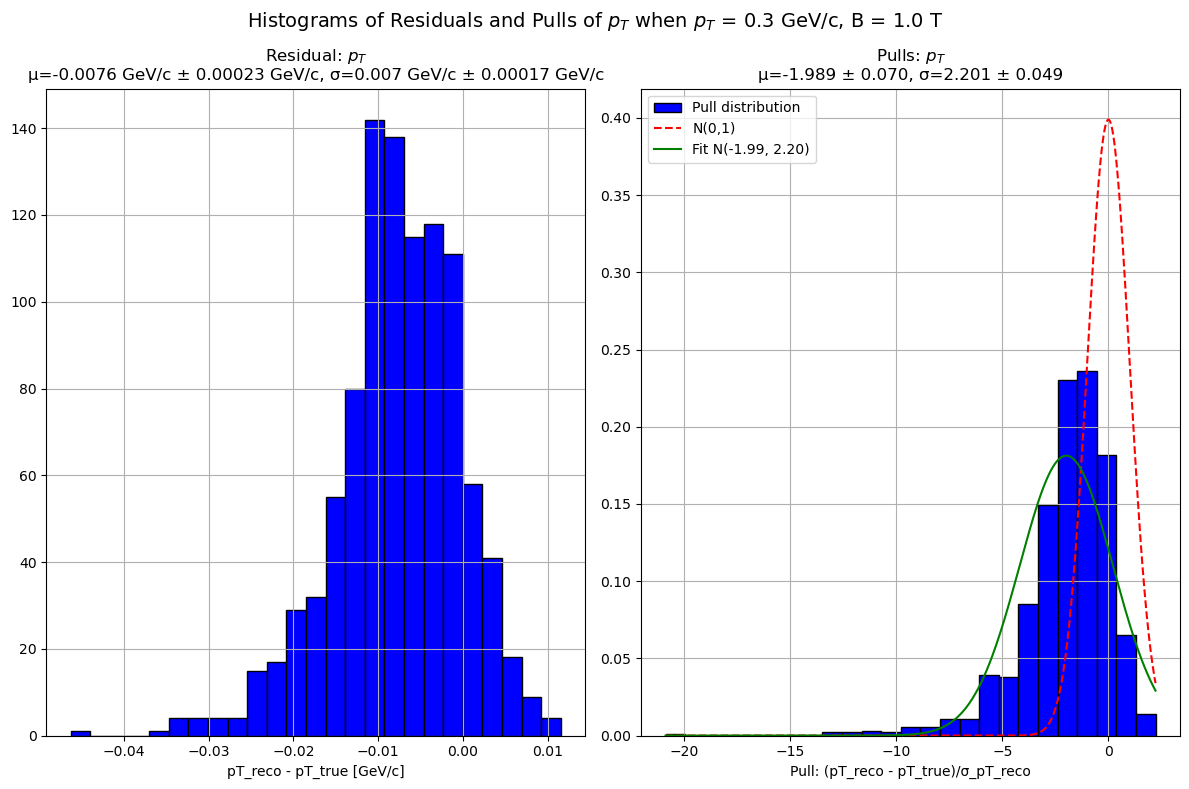

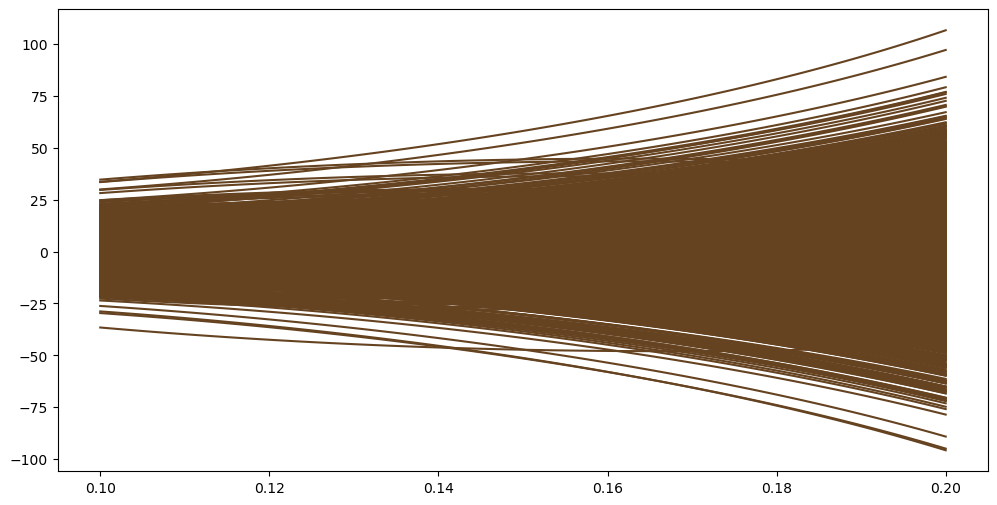

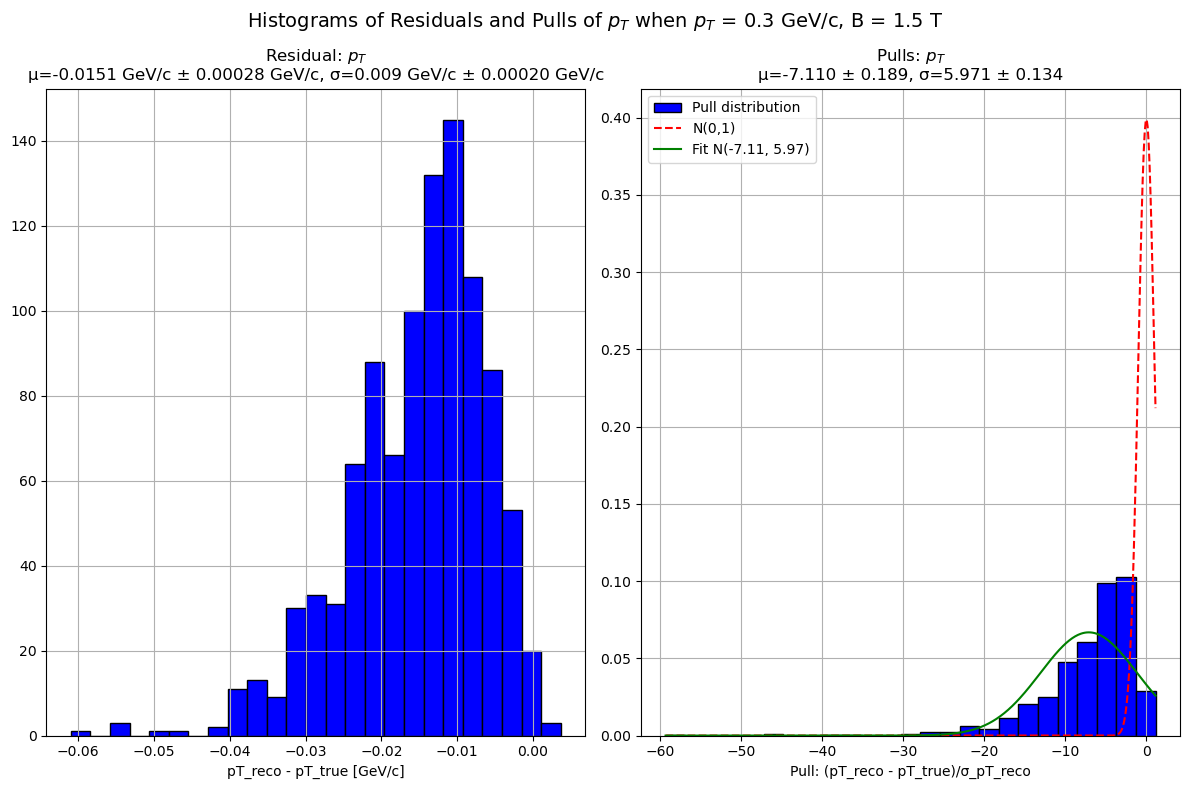

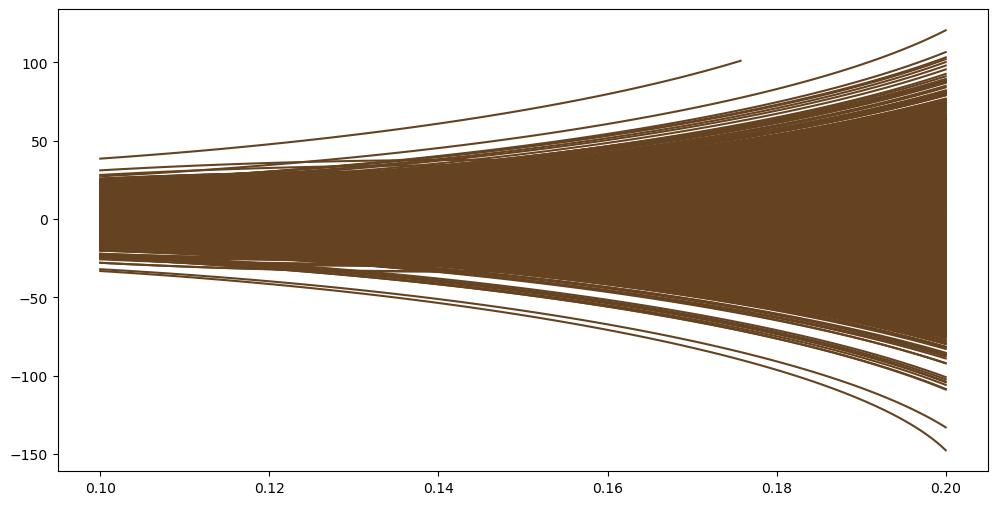

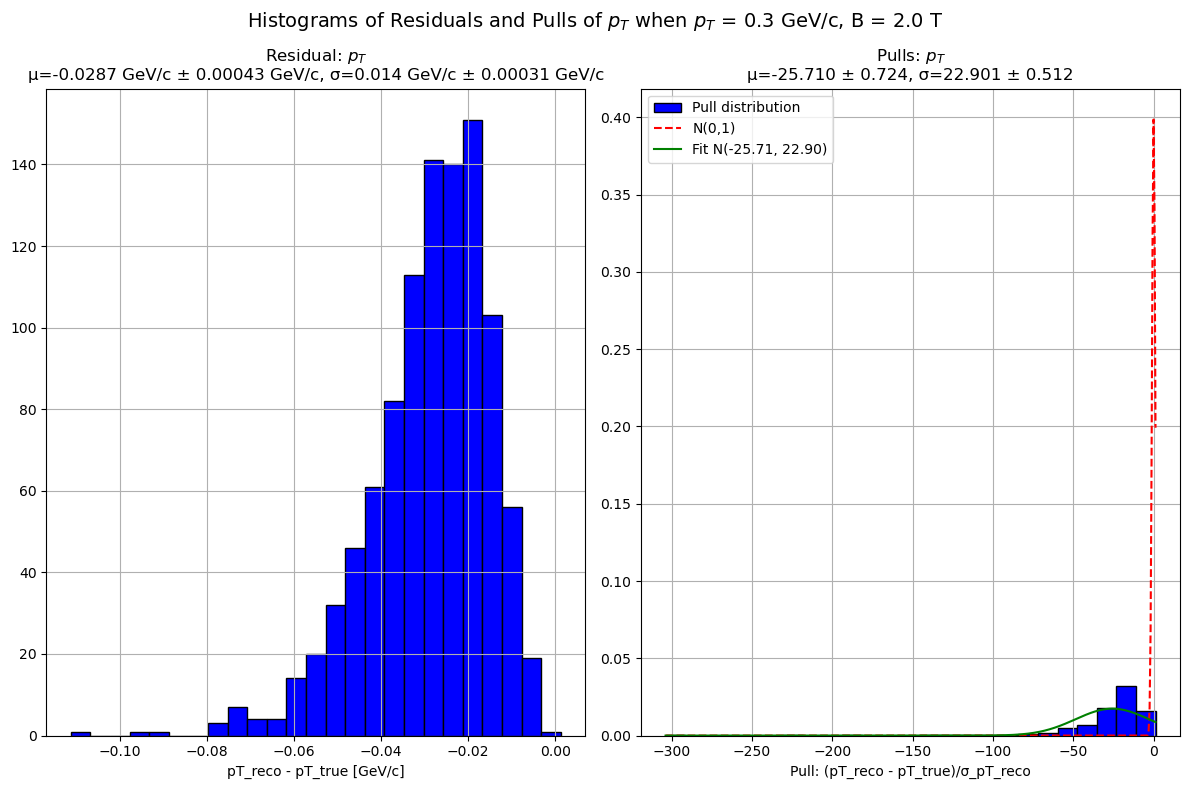

In [8]:
Bs = np.array([1.0, 1.5, 2.0]) # T
pT_true = 0.3 # GeV/c

nr_trajectories = 1000

# Simulate trajectories for each pT_true value
for B in Bs:
    #np.random.seed(14)
    plt.figure(figsize=(12,6))

    z_positions_before_B, z_positions_after_B, x_positions_before_B, x_positions_after_B, grid_before_B, grid_after_B, true_traj_z_before_B, true_traj_z_after_B, reco_traj_z_before_B, reco_traj_z_after_B, cells_hit_middle_before_B, cells_hit_middle_after_B, std_hit, s_after_B, s0_reco_before_B, s0_reco_after_B, std_x0_reco_before_B, std_s0_reco_before_B, std_x0_reco_after_B, std_s0_reco_after_B, s0, q_list = simulate_trajectories(nr_trajectories, pT_true, B)
    #display_simulation(z_positions_before_B, z_positions_after_B, x_positions_before_B, x_positions_after_B, grid_before_B, grid_after_B, true_traj_z_before_B, true_traj_z_after_B, reco_traj_z_before_B, reco_traj_z_after_B, cells_hit_middle_before_B, cells_hit_middle_after_B, std_hit, s_after_B, std_x0_reco_before_B, std_s0_reco_before_B, std_x0_reco_after_B, std_s0_reco_after_B, s0, q_list, nr_trajectories, pT_true, B)
    residuals_and_pulls(s_after_B, nr_trajectories, s0_reco_before_B, s0_reco_after_B, std_s0_reco_before_B, std_s0_reco_after_B, q_list, B, L, pT_true, pt_calculation_way= "classic")